# DNN — Parent Genre Classification
**DS340 — Multiclass Genre Classification**

## Motivation
Our initial DNN on 114 genres achieved only ~27% accuracy. Many of these genres are
acoustically indistinguishable subgenres (e.g. `rock`, `alt-rock`, `psych-rock` share
very similar audio features). 

Here we map the 114 genres into 12 parent genres and retrain.
This serves as Stage 1 of our planned hierarchical classifier.

**Architectures compared:**
- NN-A: 1 hidden layer (128)
- NN-B: 2 hidden layers (256 → 128)
- NN-C: 3 hidden layers (256 → 128 → 64)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


---
## 1. Genre Mapping: 114 → 12 Parent Genres

In [2]:
# map every subgenre to a parent genre
GENRE_MAP = {
    # Rock
    'rock': 'Rock', 'alt-rock': 'Rock', 'punk-rock': 'Rock',
    'hard-rock': 'Rock', 'psych-rock': 'Rock', 'grunge': 'Rock',
    'rock-n-roll': 'Rock', 'emo': 'Rock', 'indie': 'Rock',
    'alternative': 'Rock', 'rockabilly': 'Rock',

    # Metal
    'metal': 'Metal', 'heavy-metal': 'Metal', 'death-metal': 'Metal',
    'black-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal',
    'hardcore': 'Metal', 'goth': 'Metal', 'industrial': 'Metal',

    # Electronic
    'edm': 'Electronic', 'electronic': 'Electronic', 'techno': 'Electronic',
    'detroit-techno': 'Electronic', 'minimal-techno': 'Electronic',
    'trance': 'Electronic', 'dubstep': 'Electronic', 'drum-and-bass': 'Electronic',
    'idm': 'Electronic', 'electro': 'Electronic', 'breakbeat': 'Electronic',
    'hardstyle': 'Electronic', 'ambient': 'Electronic',

    # House/Dance
    'house': 'House/Dance', 'deep-house': 'House/Dance',
    'chicago-house': 'House/Dance', 'progressive-house': 'House/Dance',
    'dance': 'House/Dance', 'disco': 'House/Dance', 'club': 'House/Dance',
    'garage': 'House/Dance', 'dancehall': 'House/Dance',

    # Pop
    'pop': 'Pop', 'indie-pop': 'Pop', 'synth-pop': 'Pop',
    'power-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop',
    'cantopop': 'Pop', 'mandopop': 'Pop', 'j-idol': 'Pop',
    'j-dance': 'Pop', 'party': 'Pop', 'happy': 'Pop',
    'pop-film': 'Pop', 'disney': 'Pop', 'show-tunes': 'Pop',

    # Hip-Hop / R&B
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'soul': 'Hip-Hop/R&B',
    'funk': 'Hip-Hop/R&B', 'groove': 'Hip-Hop/R&B', 'trip-hop': 'Hip-Hop/R&B',

    # Latin
    'latin': 'Latin', 'latino': 'Latin', 'salsa': 'Latin',
    'samba': 'Latin', 'reggaeton': 'Latin', 'tango': 'Latin',
    'forro': 'Latin', 'pagode': 'Latin', 'sertanejo': 'Latin',
    'mpb': 'Latin', 'brazil': 'Latin', 'bossanova': 'Latin',
    'romance': 'Latin', 'spanish': 'Latin',

    # Jazz / Blues
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'gospel': 'Jazz/Blues',
    'soul': 'Jazz/Blues',

    # Classical / Instrumental
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental',
    'new-age': 'Classical/Instrumental', 'sleep': 'Classical/Instrumental',
    'study': 'Classical/Instrumental',

    # Country / Folk
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'bluegrass': 'Country/Folk',
    'honky-tonk': 'Country/Folk', 'singer-songwriter': 'Country/Folk',
    'songwriter': 'Country/Folk', 'acoustic': 'Country/Folk',

    # Reggae
    'reggae': 'Reggae', 'dub': 'Reggae', 'ska': 'Reggae',

    # World / Other
    'world-music': 'World/Other', 'afrobeat': 'World/Other',
    'indian': 'World/Other', 'iranian': 'World/Other',
    'turkish': 'World/Other', 'malay': 'World/Other',
    'french': 'World/Other', 'german': 'World/Other',
    'swedish': 'World/Other', 'british': 'World/Other',
    'j-rock': 'World/Other', 'anime': 'World/Other',
    'children': 'World/Other', 'kids': 'World/Other',
    'comedy': 'World/Other', 'sad': 'World/Other',
    'chill': 'World/Other', 'dub': 'World/Other',
}

print(f'Genre map covers {len(GENRE_MAP)} subgenres → {len(set(GENRE_MAP.values()))} parent genres')
print(f'Parent genres: {sorted(set(GENRE_MAP.values()))}')

Genre map covers 114 subgenres → 12 parent genres
Parent genres: ['Classical/Instrumental', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'House/Dance', 'Jazz/Blues', 'Latin', 'Metal', 'Pop', 'Reggae', 'Rock', 'World/Other']


---
## 2. Load & Preprocess

In [3]:
data = pd.read_csv('../Data/spotify-tracks-dataset.csv')

drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])
data = data.dropna().drop_duplicates()

# apply genre mapping
data['parent_genre'] = data['track_genre'].map(GENRE_MAP)

# drop any genres not in our map
unmapped = data[data['parent_genre'].isna()]['track_genre'].unique()
if len(unmapped) > 0:
    print(f'Unmapped genres (will assign World/Other): {unmapped}')
    data['parent_genre'] = data['parent_genre'].fillna('World/Other')

print(f'Data shape: {data.shape}')
print(f'\nParent genre distribution:')
print(data['parent_genre'].value_counts())

Unmapped genres (will assign World/Other): <StringArray>
['punk']
Length: 1, dtype: str
Data shape: (106907, 17)

Parent genre distribution:
parent_genre
World/Other               18505
Pop                       14398
Electronic                12494
Latin                     12175
Rock                       9850
Metal                      8845
House/Dance                8270
Classical/Instrumental     6738
Country/Folk               6287
Hip-Hop/R&B                4548
Jazz/Blues                 3006
Reggae                     1791
Name: count, dtype: int64


In [4]:
# sample up to 1000 per parent genre (more data now that we have fewer classes)
data = data.groupby('parent_genre').sample(n=min(1000, data.groupby('parent_genre').size().min()), random_state=42)
print(f'Sampled shape: {data.shape}')
print(data['parent_genre'].value_counts())

del_cols = [c for c in data.columns if c not in [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature', 'parent_genre'
]]
data = data.drop(columns=del_cols)

Sampled shape: (12000, 17)
parent_genre
Classical/Instrumental    1000
Country/Folk              1000
Electronic                1000
Hip-Hop/R&B               1000
House/Dance               1000
Jazz/Blues                1000
Latin                     1000
Metal                     1000
Pop                       1000
Reggae                    1000
Rock                      1000
World/Other               1000
Name: count, dtype: int64


In [5]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['parent_genre'])
num_classes = len(le.classes_)
print(f'Classes: {num_classes} — {list(le.classes_)}')

feature_cols = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X = data[feature_cols].copy()
X['explicit'] = X['explicit'].astype(int)
y = data['label'].values

del data
gc.collect()

Classes: 12 — ['Classical/Instrumental', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'House/Dance', 'Jazz/Blues', 'Latin', 'Metal', 'Pop', 'Reggae', 'Rock', 'World/Other']


20

In [6]:
# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

del X, X_temp, y_temp
gc.collect()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_sc).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val_sc).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test_sc).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True
)

print(f'Train: {X_train_sc.shape[0]:,}  Val: {X_val_sc.shape[0]:,}  Test: {X_test_sc.shape[0]:,}')

Train: 8,400  Val: 1,800  Test: 1,800


---
## 3. Train NN-A, NN-B, NN-C

In [7]:
class GenreClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(name, hidden_dims, epochs=300, patience=20, lr=0.001):
    model = GenreClassifier(
        input_dim=X_train_sc.shape[1],
        num_classes=num_classes,
        hidden_dims=hidden_dims
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(X_train_t))

        model.eval()
        with torch.no_grad():
            out = model(X_val_t)
            val_loss = criterion(out, y_val_t).item()
            val_acc  = (out.argmax(1) == y_val_t).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_val_t).argmax(1).cpu().numpy()

    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    print(f'\n{name} — Val Accuracy: {acc:.4f}, Macro F1: {f1:.4f}')

    return {
        'name': name, 'model': model,
        'accuracy': acc, 'macro_f1': f1, 'preds': preds,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

print('Model defined.')

Model defined.


In [8]:
print('=== NN-A: 1 hidden layer (128) ===')
nna = train_model('NN-A (1 layer)', hidden_dims=[128])
gc.collect()

=== NN-A: 1 hidden layer (128) ===
  Epoch  50 | Train Loss: 1.8429 | Val Loss: 1.8585 | Val Acc: 0.3661
  Epoch 100 | Train Loss: 1.7952 | Val Loss: 1.8337 | Val Acc: 0.3728
  Epoch 150 | Train Loss: 1.7718 | Val Loss: 1.8260 | Val Acc: 0.3811
  Early stop at epoch 198

NN-A (1 layer) — Val Accuracy: 0.3856, Macro F1: 0.3669


0

In [9]:
print('=== NN-B: 2 hidden layers (256 → 128) ===')
nnb = train_model('NN-B (2 layers)', hidden_dims=[256, 128])
gc.collect()

=== NN-B: 2 hidden layers (256 → 128) ===
  Epoch  50 | Train Loss: 1.7052 | Val Loss: 1.7680 | Val Acc: 0.4050
  Epoch 100 | Train Loss: 1.5785 | Val Loss: 1.7400 | Val Acc: 0.4161
  Early stop at epoch 140

NN-B (2 layers) — Val Accuracy: 0.4167, Macro F1: 0.4017


0

In [10]:
print('=== NN-C: 3 hidden layers (256 → 128 → 64) ===')
nnc = train_model('NN-C (3 layers)', hidden_dims=[256, 128, 64])
gc.collect()

=== NN-C: 3 hidden layers (256 → 128 → 64) ===
  Epoch  50 | Train Loss: 1.7495 | Val Loss: 1.7677 | Val Acc: 0.4133
  Epoch 100 | Train Loss: 1.6361 | Val Loss: 1.7292 | Val Acc: 0.4272
  Early stop at epoch 135

NN-C (3 layers) — Val Accuracy: 0.4233, Macro F1: 0.4120


0

---
## 4. Compare Results

In [11]:
results = pd.DataFrame([
    {'Model': r['name'], 'Accuracy': r['accuracy'], 'Macro F1': r['macro_f1']}
    for r in [nna, nnb, nnc]
])

# comparison with original 114-class DNN for context
context = pd.DataFrame([
    {'Model': 'DNN (114 genres, no mapping)', 'Accuracy': 0.2688, 'Macro F1': 0.2396},
    {'Model': 'Random Forest (114 genres)', 'Accuracy': 0.3019, 'Macro F1': 0.2834},
])

all_results = pd.concat([context, results], ignore_index=True)
print('=== Results Comparison ===')
print(all_results.to_string(index=False))

=== Results Comparison ===
                       Model  Accuracy  Macro F1
DNN (114 genres, no mapping)  0.268800  0.239600
  Random Forest (114 genres)  0.301900  0.283400
              NN-A (1 layer)  0.385556  0.366868
             NN-B (2 layers)  0.416667  0.401662
             NN-C (3 layers)  0.423333  0.412023


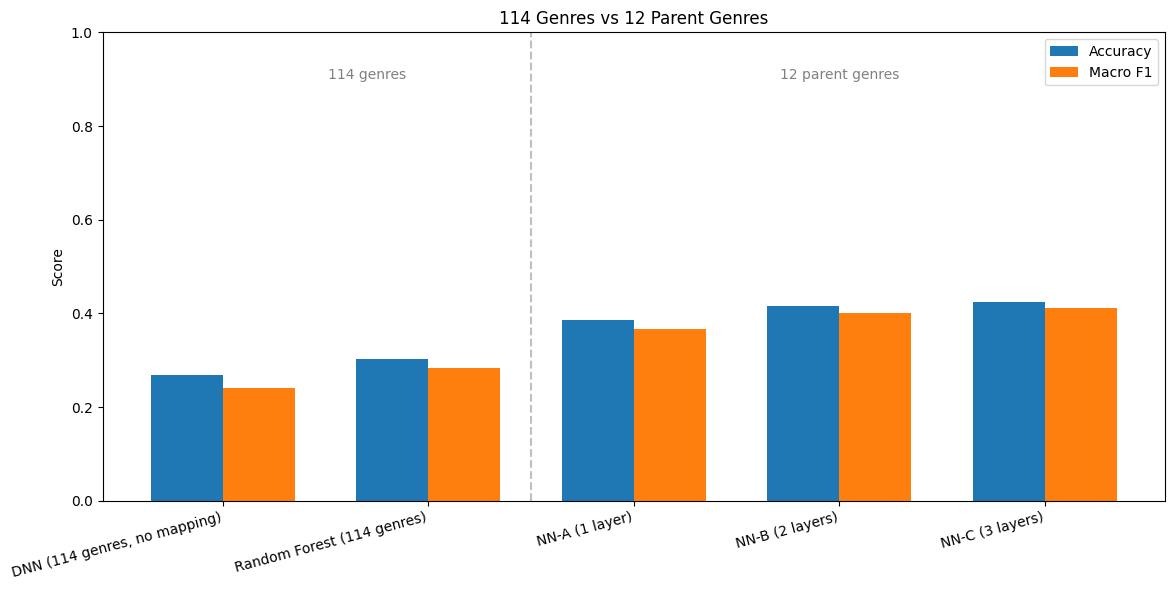

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
width = 0.35
ax.bar(x - width/2, all_results['Accuracy'], width, label='Accuracy')
ax.bar(x + width/2, all_results['Macro F1'], width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('114 Genres vs 12 Parent Genres')
ax.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
ax.text(0.7, 0.9, '114 genres', transform=ax.get_xaxis_transform(), ha='center', color='gray')
ax.text(3.0, 0.9, '12 parent genres', transform=ax.get_xaxis_transform(), ha='center', color='gray')
ax.legend()
plt.tight_layout()
plt.show()

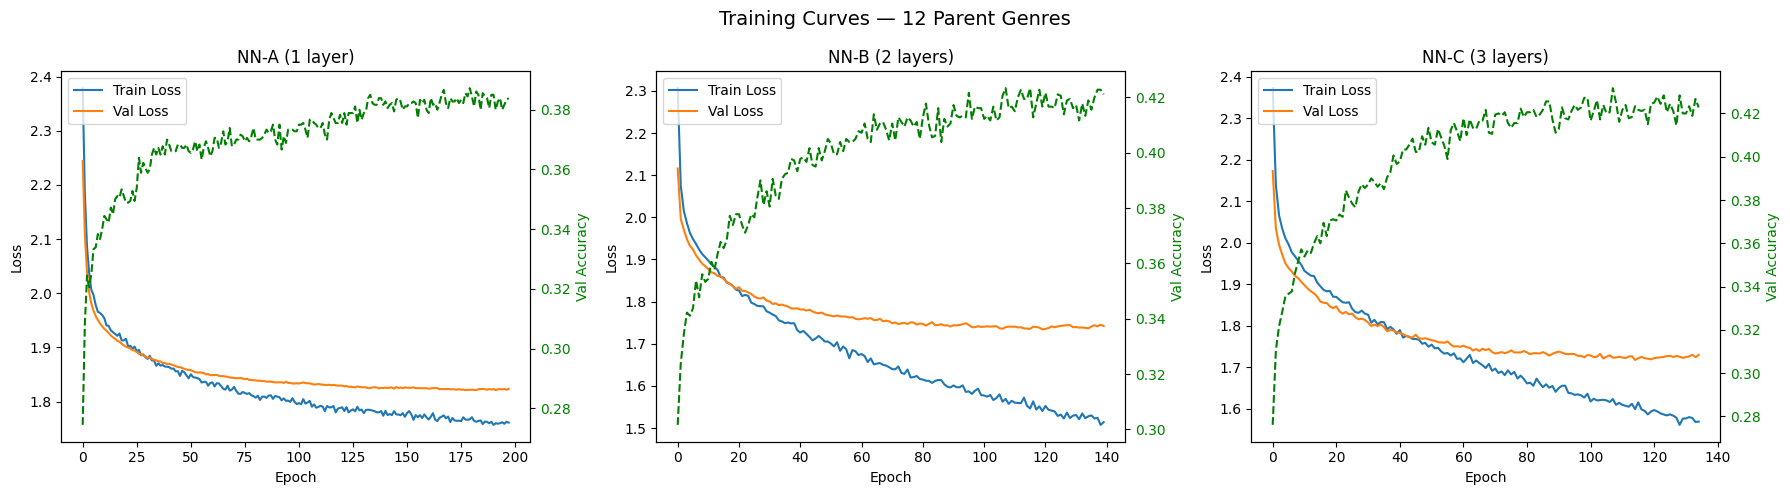

In [13]:
# training curves for all 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, [nna, nnb, nnc]):
    ax.plot(r['train_losses'], label='Train Loss')
    ax.plot(r['val_losses'], label='Val Loss')
    ax2 = ax.twinx()
    ax2.plot(r['val_accs'], color='green', linestyle='--', label='Val Acc')
    ax2.set_ylabel('Val Accuracy', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax.set_title(r['name'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper left')
plt.suptitle('Training Curves — 12 Parent Genres', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Best Model — Detailed Evaluation

In [14]:
best = max([nna, nnb, nnc], key=lambda r: r['macro_f1'])
print(f'Best architecture: {best["name"]}\n')
print(classification_report(y_val, best['preds'], target_names=le.classes_))

Best architecture: NN-C (3 layers)

                        precision    recall  f1-score   support

Classical/Instrumental       0.61      0.71      0.66       150
          Country/Folk       0.37      0.51      0.43       150
            Electronic       0.54      0.39      0.46       150
           Hip-Hop/R&B       0.32      0.18      0.23       150
           House/Dance       0.32      0.35      0.33       150
            Jazz/Blues       0.45      0.45      0.45       150
                 Latin       0.43      0.38      0.40       150
                 Metal       0.55      0.64      0.59       150
                   Pop       0.34      0.34      0.34       150
                Reggae       0.39      0.63      0.48       150
                  Rock       0.31      0.32      0.31       150
           World/Other       0.45      0.18      0.26       150

              accuracy                           0.42      1800
             macro avg       0.42      0.42      0.41      1800
  

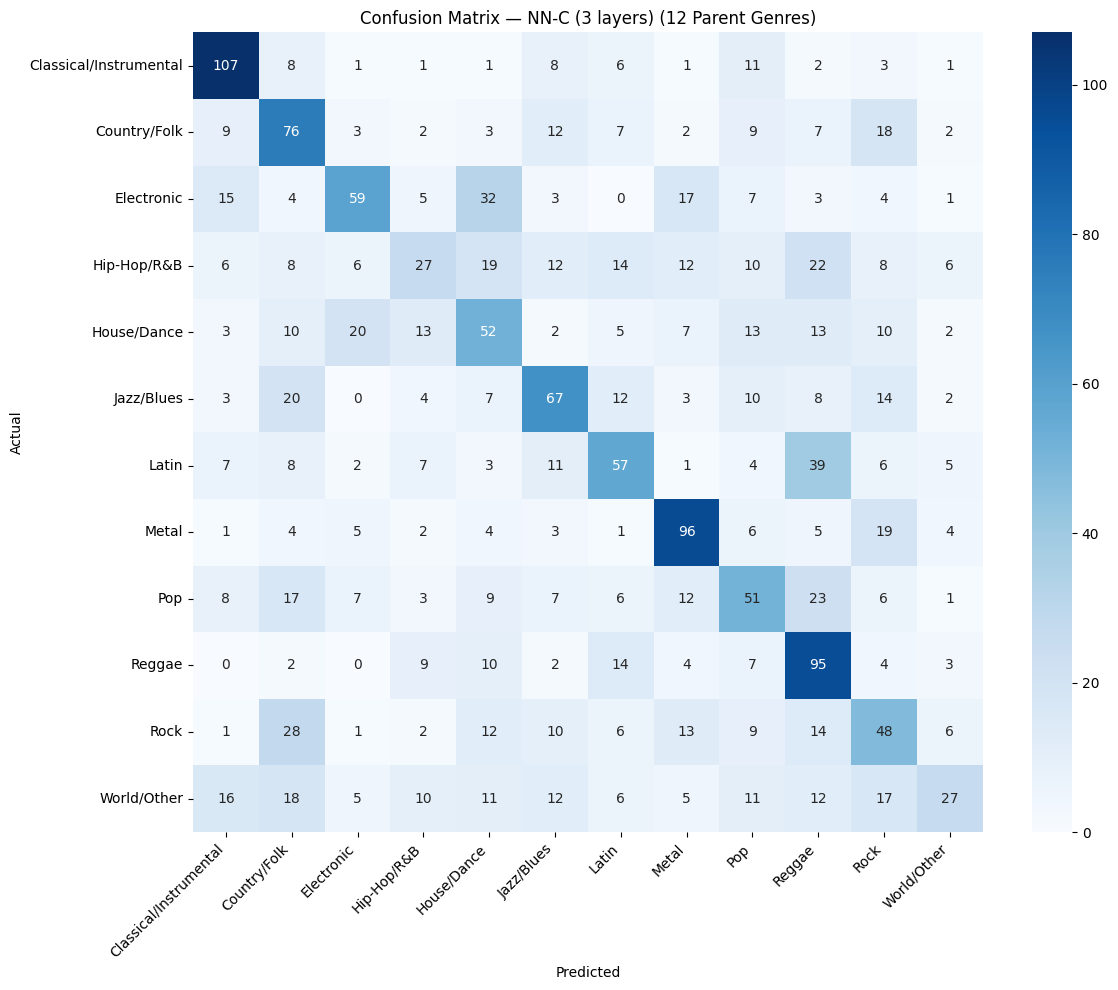

In [15]:
cm = confusion_matrix(y_val, best['preds'])

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f'Confusion Matrix — {best["name"]} (12 Parent Genres)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Test Set — Final Score
Run this only once when done tuning.

In [16]:
best['model'].eval()
with torch.no_grad():
    test_preds = best['model'](X_test_t).argmax(1).cpu().numpy()

print(f'{best["name"]} — TEST SET')
print(f'Accuracy: {accuracy_score(y_test, test_preds):.4f}')
print(f'Macro F1: {f1_score(y_test, test_preds, average="macro"):.4f}')

NN-C (3 layers) — TEST SET
Accuracy: 0.4200
Macro F1: 0.4080


---
## Next Steps
- Use best architecture here as **Stage 1** of the hierarchical classifier
- Build Stage 2: per-parent-genre subgenre classifier (Week 5)
- Hyperparameter tuning on best architecture

---
## 7. Improved Model — Techniques from Reference CNN Paper

Inspired by [Music Genre Classification Using CNNs](https://github.com/crlandsc/Music-Genre-Classification-Using-Convolutional-Neural-Networks), which improved accuracy from **69.1% → 80.1% → 83.8%** using:

1. **BatchNorm** after each linear layer — stabilizes training, acts as implicit regularization
2. **Gaussian noise augmentation** — tabular analog of horizontal spectrogram flipping
3. **ReduceLROnPlateau** scheduler — prevents overshooting once loss plateaus
4. **Wider architecture**: 512 → 256 → 128 → 64 with more epochs (400)

In [ ]:
class ImprovedGenreClassifier(nn.Module):
    """
    DNN with BatchNorm after each linear layer.
    BatchNorm stabilizes gradient flow, allowing deeper/wider networks
    to train reliably — the same effect the reference paper saw from
    adding regularization to their CNN.
    """
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.4):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_improved_model(name, hidden_dims, epochs=400, patience=30, lr=0.001,
                         noise_std=0.05, dropout=0.4):
    """
    Training loop with:
    - Gaussian noise augmentation on each batch (analog to spectrogram flipping)
    - ReduceLROnPlateau scheduler (reference paper: 400 epochs, measured LR decay)
    - Early stopping with generous patience
    """
    model = ImprovedGenreClassifier(
        input_dim=X_train_sc.shape[1],
        num_classes=num_classes,
        hidden_dims=hidden_dims,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        # ---- train with Gaussian noise augmentation ----
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            noise = torch.randn_like(xb) * noise_std   # add small Gaussian noise
            xb_aug = xb + noise
            optimizer.zero_grad()
            loss = criterion(model(xb_aug), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(X_train_t))

        # ---- validate (no augmentation) ----
        model.eval()
        with torch.no_grad():
            out = model(X_val_t)
            val_loss = criterion(out, y_val_t).item()
            val_acc  = (out.argmax(1) == y_val_t).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        # ---- early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | Train: {train_losses[-1]:.4f} | '
                  f'Val: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
                  f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_val_t).argmax(1).cpu().numpy()

    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    print(f'\n{name} — Val Accuracy: {acc:.4f}, Macro F1: {f1:.4f}')

    return {
        'name': name, 'model': model,
        'accuracy': acc, 'macro_f1': f1, 'preds': preds,
        'train_losses': train_losses, 'val_losses': val_losses, 'val_accs': val_accs,
    }

print('ImprovedGenreClassifier and training function defined.')

In [ ]:
# NN-D: Wider architecture (512 → 256 → 128 → 64) with all improvements
print('=== NN-D: Improved (BatchNorm + Noise Aug + LR Scheduler) ===')
print('Architecture: 512 → 256 → 128 → 64 | Dropout=0.4 | noise_std=0.05\n')
nnd = train_improved_model(
    'NN-D (Improved)',
    hidden_dims=[512, 256, 128, 64],
    epochs=400,
    patience=30,
    lr=0.001,
    noise_std=0.05,
    dropout=0.4,
)
gc.collect()

In [ ]:
# Full comparison: all models including improved
all_models = [nna, nnb, nnc, nnd]

comparison = pd.DataFrame([
    {'Model': r['name'], 'Accuracy': r['accuracy'], 'Macro F1': r['macro_f1']}
    for r in all_models
])

context = pd.DataFrame([
    {'Model': 'Random Forest (114 genres)', 'Accuracy': 0.3019, 'Macro F1': 0.2834},
    {'Model': 'DNN (114 genres, no mapping)', 'Accuracy': 0.2688, 'Macro F1': 0.2396},
])

full = pd.concat([context, comparison], ignore_index=True)
print('=== All Models — Validation Set ===')
print(full.to_string(index=False))
print(f'\nImprovement over NN-C: +{nnd["accuracy"] - nnc["accuracy"]:+.4f} accuracy')

In [ ]:
# Training curve for NN-D
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nnd['train_losses'], label='Train Loss')
ax.plot(nnd['val_losses'], label='Val Loss')
ax2 = ax.twinx()
ax2.plot(nnd['val_accs'], color='green', linestyle='--', label='Val Acc')
ax2.set_ylabel('Val Accuracy', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax.set_title('NN-D (Improved): BatchNorm + Noise Augmentation + LR Scheduling')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(classification_report(y_val, nnd['preds'], target_names=le.classes_))

## AI Usage
- Used Claude to generate the genre mapping, DNN architecture, and training loop
- Used Claude to structure the comparison between 114-genre and 12-genre approaches